<a href="https://colab.research.google.com/github/luisrodriguez2498/Proyecto-Alura-Latam---Luis-Rodriguez/blob/main/Proyecto_Alura_Latam_Luis_Rodriguez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importación de datos



In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



Como primer paso, unimos los datos en un único `DataFrame`.

In [3]:
datos = pd.concat([tienda, tienda2, tienda3, tienda4], ignore_index=True)

datos

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359
...,...,...,...,...,...,...,...,...,...,...,...,...
9430,Mesa de comedor,Muebles,227700.0,12600.0,12/02/2020,Camila Rivera,Medellín,5,Tarjeta de crédito,1,6.25184,-75.56359
9431,Silla de oficina,Muebles,342000.0,18600.0,17/05/2022,Felipe Santos,Bucaramanga,5,Tarjeta de crédito,3,7.12539,-73.11980
9432,Vaso térmico,Deportes y diversión,36700.0,2400.0,03/05/2022,Camila Rivera,Bogotá,5,Tarjeta de crédito,1,4.60971,-74.08175
9433,Set de ollas,Artículos para el hogar,151800.0,8300.0,15/06/2020,Blanca Ramirez,Cali,5,Tarjeta de crédito,1,3.43722,-76.52250


Verificamos si hay datos faltantes en las columnas relevantes.

In [14]:
print(datos.isnull().sum())

Producto                  0
Categoría del Producto    0
Precio                    0
Costo de envío            0
Fecha de Compra           0
Vendedor                  0
Lugar de Compra           0
Calificación              0
Método de pago            0
Cantidad de cuotas        0
lat                       0
lon                       0
Facturación Total         0
dtype: int64


In [5]:
datos = datos.dropna(subset=["Producto", "Precio", "Cantidad de cuotas"])

Para analizar la facturacion total, utilizamos las columnas `Precio` y `Cantidad de cuotas`.

In [6]:
datos["Facturación Total"] = datos["Precio"] * datos["Cantidad de cuotas"]

Agrupamos los datos por la columna `Categoria del producto` para calcular el total por categoria.

In [7]:
facturacion_por_categoria = datos.groupby("Categoría del Producto")["Facturación Total"].sum()
print(facturacion_por_categoria)

Categoría del Producto
Artículos para el hogar    1.703604e+08
Deportes y diversión       4.320055e+08
Electrodomésticos          4.019072e+09
Electrónicos               4.889815e+09
Instrumentos musicales     1.044612e+09
Juguetes                   2.116156e+08
Libros                     1.130887e+08
Muebles                    2.221981e+09
Name: Facturación Total, dtype: float64


Exploramos cual metodo de pago tiene mayor impacto en la facturacion.

In [8]:
facturacion_por_metodo = datos.groupby("Método de pago")["Facturación Total"].sum()
print(facturacion_por_metodo)

Método de pago
Cupón                 2.358696e+08
Nequi                 8.806842e+08
Tarjeta de crédito    1.192954e+10
Tarjeta de débito     5.645830e+07
Name: Facturación Total, dtype: float64


Y ahora utilizamos gráficos para presentar los analisis.

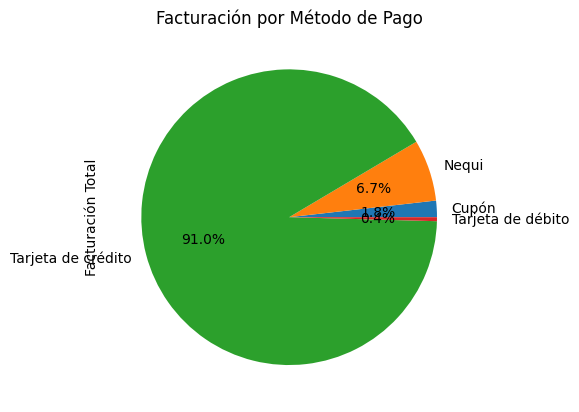

In [9]:
# Facturación por método de pago
facturacion_por_metodo.plot(kind="pie", autopct="%1.1f%%", title="Facturación por Método de Pago")
plt.show()

In [10]:
facturacion_por_lugar = datos.groupby("Lugar de Compra")["Facturación Total"].sum()
print(facturacion_por_lugar)

Lugar de Compra
Armenia          3.758590e+07
Barranquilla     4.373335e+08
Bogotá           4.957477e+09
Bucaramanga      3.137693e+08
Cali             1.476514e+09
Cartagena        3.729088e+08
Cúcuta           3.276642e+08
Inírida          3.876210e+07
Leticia          1.847413e+08
Manizales        7.373690e+07
Medellín         3.342985e+09
Neiva            7.485350e+07
Pasto            1.578270e+08
Pereira          7.212818e+08
Riohacha         2.523902e+08
Santa Marta      2.126688e+08
Soacha           4.678280e+07
Valledupar       1.743050e+07
Villavicencio    5.583840e+07
Name: Facturación Total, dtype: float64


In [11]:
facturacion_por_categoria.to_csv("facturacion_por_categoria.csv")

# 2. Ventas por categoría

Para calular las ventas totales por cada categoria de producto, agruparemos los datos por la columna `Categoria del producto` y sumemos las ventas totales. (`Precio * Cantidad de cuotas`).

In [12]:
# Crear columna para el total de ventas
datos["Facturación Total"] = datos["Precio"] * datos["Cantidad de cuotas"]

# Agrupar por categoría y calcular la facturación total
ventas_por_categoria = datos.groupby("Categoría del Producto")["Facturación Total"].sum()
print(ventas_por_categoria)

Categoría del Producto
Artículos para el hogar    1.703604e+08
Deportes y diversión       4.320055e+08
Electrodomésticos          4.019072e+09
Electrónicos               4.889815e+09
Instrumentos musicales     1.044612e+09
Juguetes                   2.116156e+08
Libros                     1.130887e+08
Muebles                    2.221981e+09
Name: Facturación Total, dtype: float64


Ahora podemos usar graficos para presentar los resultados de manera clara. A continuacion, un grafico de barras que muestra las ventas por categorias.

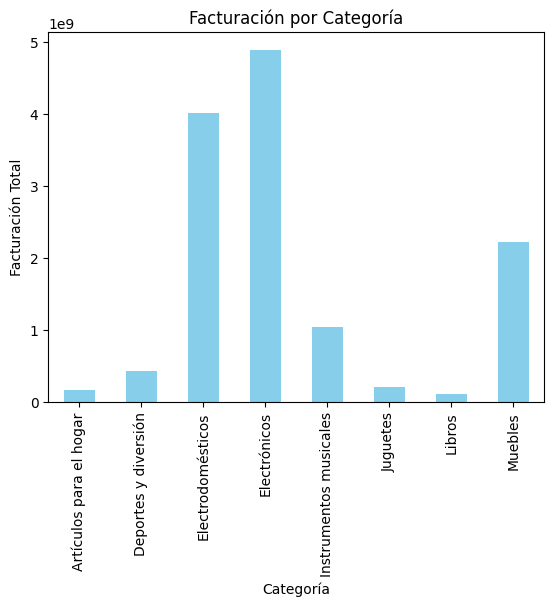

In [13]:
import matplotlib.pyplot as plt

# Facturación por categoría
facturacion_por_categoria.plot(kind="bar", title="Facturación por Categoría", xlabel="Categoría", ylabel="Facturación Total", color="skyblue")
plt.show()

# 3. Calificación promedio de la tienda


Dado que tenemos una columna llamada `Calificación`, puedes calcular el promedio general con:

In [17]:
calificacion_promedio = datos["Calificación"].mean()
print(f"Calificación promedio de la tienda: {calificacion_promedio:.2f}")

Calificación promedio de la tienda: 4.01


# 4. Productos más y menos vendidos

Esto nos dará el número total de unidades vendidas por cada producto.

In [18]:
productos_vendidos = datos.groupby("Producto")["Cantidad de cuotas"].sum()


Ordenamos en orden ascendente para ver los productos con menor cantidad de ventas:

In [19]:
productos_mas_vendidos = productos_vendidos.sort_values(ascending=False)
print(productos_mas_vendidos.head(10))  # Muestra los 10 productos más vendidos


Producto
Secadora de ropa     649
Mesa de noche        627
Pandereta            625
Bicicleta            614
Iphone 15            611
Cama king            603
Set de ollas         601
Microondas           600
Guitarra acústica    595
Batería              595
Name: Cantidad de cuotas, dtype: int64


Podemos usar un gráfico de barras para representar los productos más vendidos:

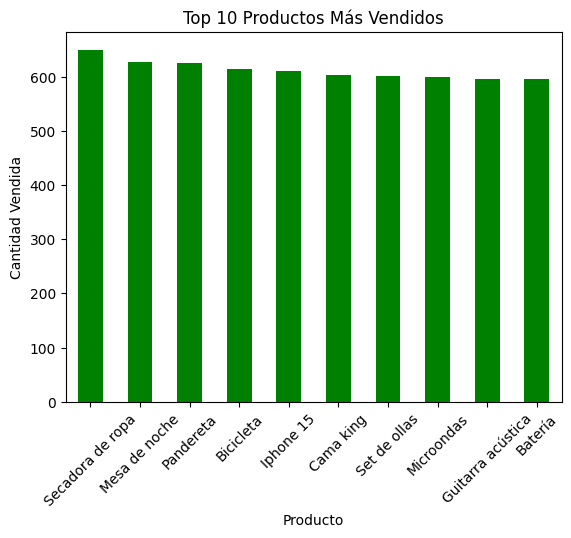

In [21]:
import matplotlib.pyplot as plt

productos_mas_vendidos.head(10).plot(kind="bar", color="green", title="Top 10 Productos Más Vendidos", ylabel="Cantidad Vendida", xlabel="Producto")
plt.xticks(rotation=45)
plt.show()


Y también uno para los menos vendidos:

In [20]:
productos_menos_vendidos = productos_vendidos.sort_values(ascending=True)
print(productos_menos_vendidos.head(10))  # Muestra los 10 productos menos vendidos


Producto
Smartwatch            432
Set de vasos          435
Celular ABXY          447
Dinosaurio Rex        458
Mesa de centro        469
Mochila               471
Muñeca bebé           474
Cubo mágico 8x8       487
Guitarra eléctrica    497
Tablet ABXY           497
Name: Cantidad de cuotas, dtype: int64


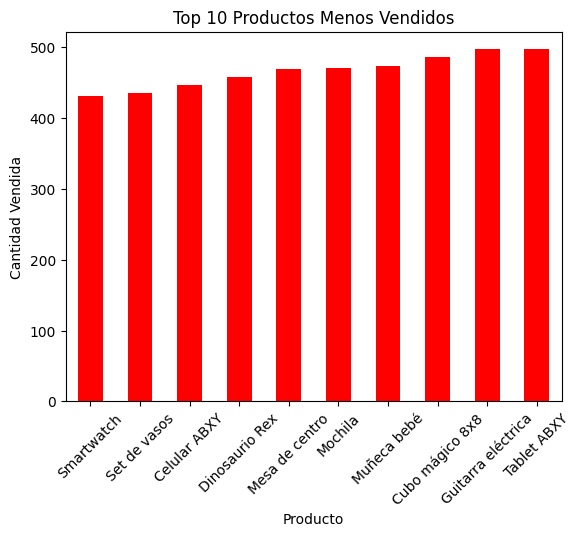

In [22]:
productos_menos_vendidos.head(10).plot(kind="bar", color="red", title="Top 10 Productos Menos Vendidos", ylabel="Cantidad Vendida", xlabel="Producto")
plt.xticks(rotation=45)
plt.show()


# 5. Envío promedio por tienda

Agrupamos los datos por `Lugar de Compra` y calculamos el promedio del `Costo de envío`:

In [23]:
envios_por_tienda = datos.groupby("Lugar de Compra")["Costo de envío"].mean()
print(envios_por_tienda)


Lugar de Compra
Armenia          22867.857143
Barranquilla     22692.258065
Bogotá           24532.082171
Bucaramanga      26790.055249
Cali             26726.812314
Cartagena        22638.429752
Cúcuta           28597.311828
Inírida          30557.142857
Leticia          25317.605634
Manizales        24948.780488
Medellín         25282.022472
Neiva            27710.000000
Pasto            27801.063830
Pereira          23211.411992
Riohacha         24127.607362
Santa Marta      18752.317881
Soacha           34768.421053
Valledupar       22021.428571
Villavicencio    25100.000000
Name: Costo de envío, dtype: float64


Esto organizará las tiendas desde la que tiene menor costo de envío hasta la que tiene mayor.

In [24]:
envios_por_tienda_ordenado = envios_por_tienda.sort_values(ascending=True)
print(envios_por_tienda_ordenado)


Lugar de Compra
Santa Marta      18752.317881
Valledupar       22021.428571
Cartagena        22638.429752
Barranquilla     22692.258065
Armenia          22867.857143
Pereira          23211.411992
Riohacha         24127.607362
Bogotá           24532.082171
Manizales        24948.780488
Villavicencio    25100.000000
Medellín         25282.022472
Leticia          25317.605634
Cali             26726.812314
Bucaramanga      26790.055249
Neiva            27710.000000
Pasto            27801.063830
Cúcuta           28597.311828
Inírida          30557.142857
Soacha           34768.421053
Name: Costo de envío, dtype: float64


Visualizamos los datos para identificar patrones mas facilmente.

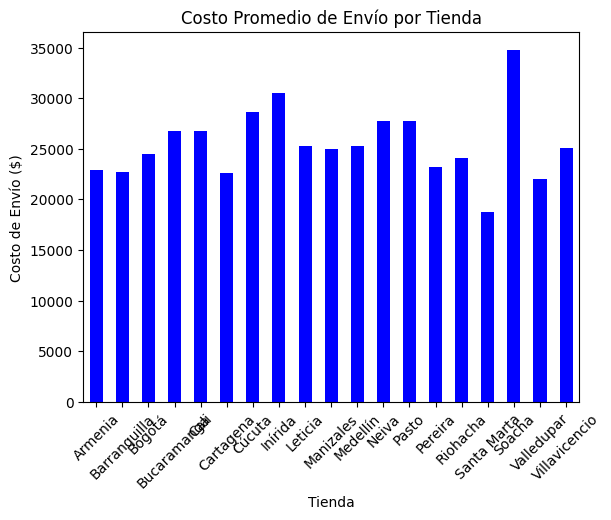

In [25]:
import matplotlib.pyplot as plt

envios_por_tienda.plot(kind="bar", color="blue", title="Costo Promedio de Envío por Tienda", ylabel="Costo de Envío ($)", xlabel="Tienda")
plt.xticks(rotation=45)
plt.show()
